# Analysis Main Notebook

이 노트북은 `Analysis`의 공개 인터페이스를 통해 실험 결과를 확인합니다.
내부 구현은 `Analysis/internal` 아래에 있지만, 노트북에서는 `from Analysis import ...` 형태만 사용합니다.
SSH 환경에서도 결과를 확인할 수 있도록 그래프는 `trends`, 표와 JSON 요약은 `final` 디렉토리에 저장합니다.

## 0. 공통 설정

In [1]:
from pathlib import Path
import sys

import pandas as pd

# 노트북 서버가 어느 디렉토리에서 시작되더라도 프로젝트 루트를 찾아 import 경로에 추가합니다.
# `.git`이 있는 위치를 루트로 보고, 모든 결과 경로도 이 루트를 기준으로 계산합니다.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / ".git").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# `Analysis` 루트는 외부 사용자를 위한 공개 인터페이스입니다.
# 내부 구현 파일은 `Analysis/internal`에 있어도 여기서는 직접 import하지 않습니다.
from Analysis import (
    Analyzer,
    calcStats,
    coverSummary,
    finalPoints,
    listBands,
    loadAlgoRuns,
    nearestStats,
    plotConverge,
    printStats,
    reportCluster,
    saveReport,
)

RESULTS_ROOT = REPO_ROOT / "__RESULTS__"
REQUESTED_ALGORITHMS = ["ga", "pso", "drl", "greedy"]
PREFERRED_MAP_NAME = "seocho.down"
SEED_BAND = None
GRID_M = 5.0
TARGET_VALUES = (2, 3)
SENSOR_COUNT_INCLUDE_CORNERS = False

ANALYSIS_ROOT = RESULTS_ROOT / "analysis"


def normalizeAlgorithms(value: str | list[str] | tuple[str, ...]) -> list[str]:
    if isinstance(value, str):
        return [value]
    return [str(item) for item in value]


def listAvailableMaps(algorithms: list[str]) -> list[str]:
    map_names: set[str] = set()
    for algorithm in algorithms:
        algorithm_root = RESULTS_ROOT / algorithm
        if not algorithm_root.exists():
            continue
        map_names.update(path.name for path in algorithm_root.iterdir() if path.is_dir())
    return sorted(map_names)


def selectMap(preferred_map: str, algorithms: list[str]) -> str:
    available_maps = listAvailableMaps(algorithms)
    if preferred_map in available_maps:
        return preferred_map
    if not available_maps:
        raise FileNotFoundError(f"No map result directories found under {RESULTS_ROOT}")
    selected_map = available_maps[0]
    print(f"preferred map {preferred_map!r} not found; using {selected_map!r}")
    return selected_map


def hasResultDir(algorithm: str, map_name: str) -> bool:
    return (RESULTS_ROOT / algorithm / map_name).exists()


def selectAlgorithms(algorithms: list[str], map_name: str) -> list[str]:
    available = [algorithm for algorithm in algorithms if hasResultDir(algorithm, map_name)]
    missing = [algorithm for algorithm in algorithms if algorithm not in available]
    if missing:
        print(f"missing result directories skipped for map={map_name!r}: {missing}")
    if not available:
        raise FileNotFoundError(
            f"No result directories found for map={map_name!r} under {RESULTS_ROOT}"
        )
    return available


def buildContext(algorithm: str, map_name: str) -> dict[str, object]:
    bands = listBands(
        results_root=RESULTS_ROOT,
        algorithm=algorithm,
        map_name=map_name,
    )
    selected_band = SEED_BAND if SEED_BAND is not None else (bands[0] if bands else None)
    map_dir_name = map_name.replace("/", "_")
    map_algo_dir = ANALYSIS_ROOT / map_dir_name / algorithm
    trends_dir = map_algo_dir / "trends"
    final_dir = map_algo_dir / "final"
    trends_dir.mkdir(parents=True, exist_ok=True)
    final_dir.mkdir(parents=True, exist_ok=True)
    return {
        "algorithm": algorithm,
        "bands": bands,
        "selected_band": selected_band,
        "run_dir": RESULTS_ROOT / algorithm / map_name,
        "single_run_dir": RESULTS_ROOT / algorithm / map_name / selected_band
        if selected_band
        else RESULTS_ROOT / algorithm / map_name,
        "trends_dir": trends_dir,
        "final_dir": final_dir,
        "report_dir": trends_dir,
    }


REQUESTED_ALGORITHMS = normalizeAlgorithms(REQUESTED_ALGORITHMS)
MAP_NAME = selectMap(PREFERRED_MAP_NAME, REQUESTED_ALGORITHMS)
ALGORITHMS = selectAlgorithms(REQUESTED_ALGORITHMS, MAP_NAME)
CONTEXTS = {algorithm: buildContext(algorithm, MAP_NAME) for algorithm in ALGORITHMS}
print(f"selected map: {MAP_NAME}")
print(f"selected algorithms: {ALGORITHMS}")
pd.DataFrame.from_dict(CONTEXTS, orient="index")[["selected_band", "trends_dir", "final_dir"]]


preferred map 'seocho.down' not found; using 'gangjin.down'
missing result directories skipped for map='gangjin.down': ['pso', 'drl', 'greedy']
selected map: gangjin.down
selected algorithms: ['ga']


,selected_band,trends_dir,final_dir
ga,20-60,/workspace/__RESULTS__/analysis/gangjin.down/g...,/workspace/__RESULTS__/analysis/gangjin.down/g...


## 1. 결과 파일과 seed band 확인

In [2]:
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    bands = list(context["bands"])
    records = loadAlgoRuns(
        results_root=RESULTS_ROOT,
        algorithm=algorithm,
        map_name=MAP_NAME,
        seed_band=SEED_BAND,
    )
    context["records"] = records
    print(f"[{algorithm}] seed bands: {bands}")
    print(f"[{algorithm}] run count: {len(records)}")

pd.DataFrame(
    {
        algorithm: {
            "bands": len(context["bands"]),
            "runs": len(context["records"]),
            "selected_band": context["selected_band"],
        }
        for algorithm, context in CONTEXTS.items()
    }
).T


[ga] seed bands: ['20-60']
[ga] run count: 100


,bands,runs,selected_band
ga,1,100,20-60


## 2. 단일 run 세대별 추이

`Analyzer`는 공개 인터페이스에서 가져오지만 실제 구현은 `Analysis/internal`에 있습니다.
선택된 seed band의 첫 번째 JSON run을 기준으로 센서 수, 커버리지, fitness 추이를 노트북에 표시하고 PNG로 저장합니다.
센서 수 그래프는 내부 배치 알고리즘이 추가한 센서만 비교하기 위해 corner 센서를 제외합니다.

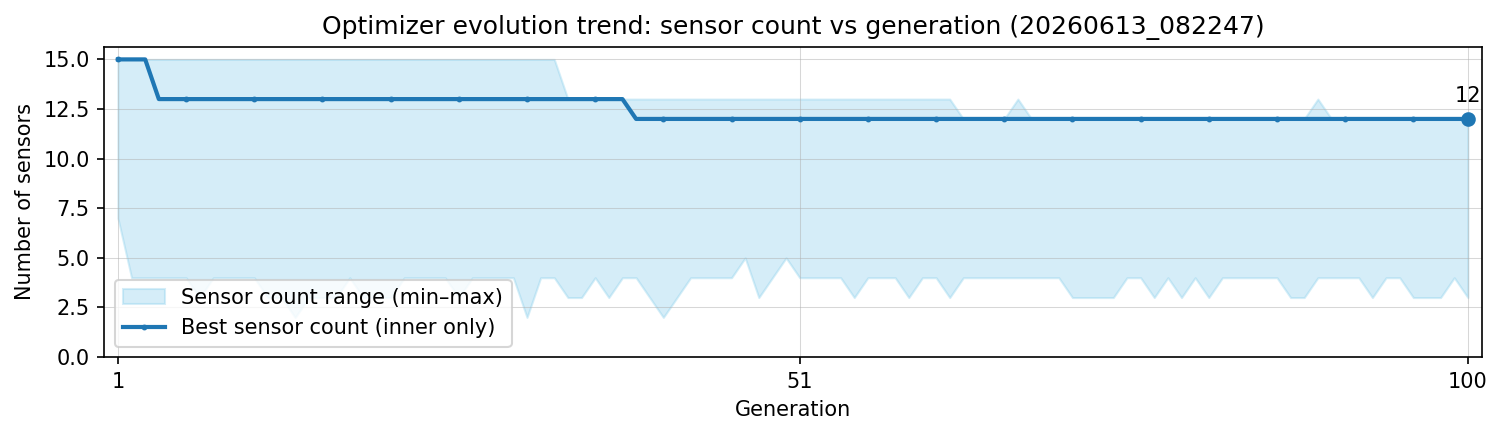

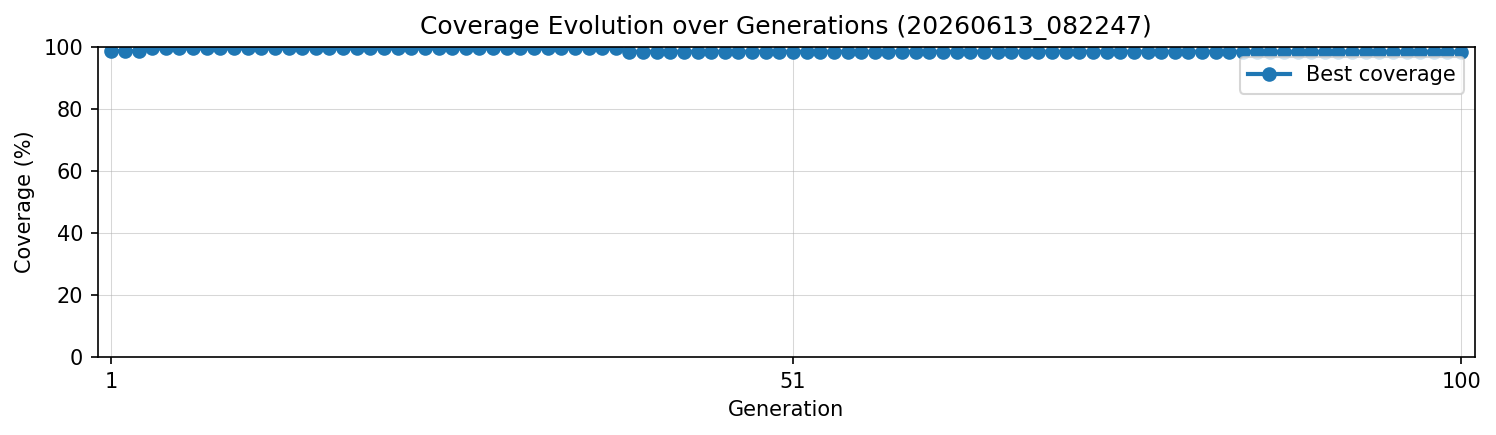

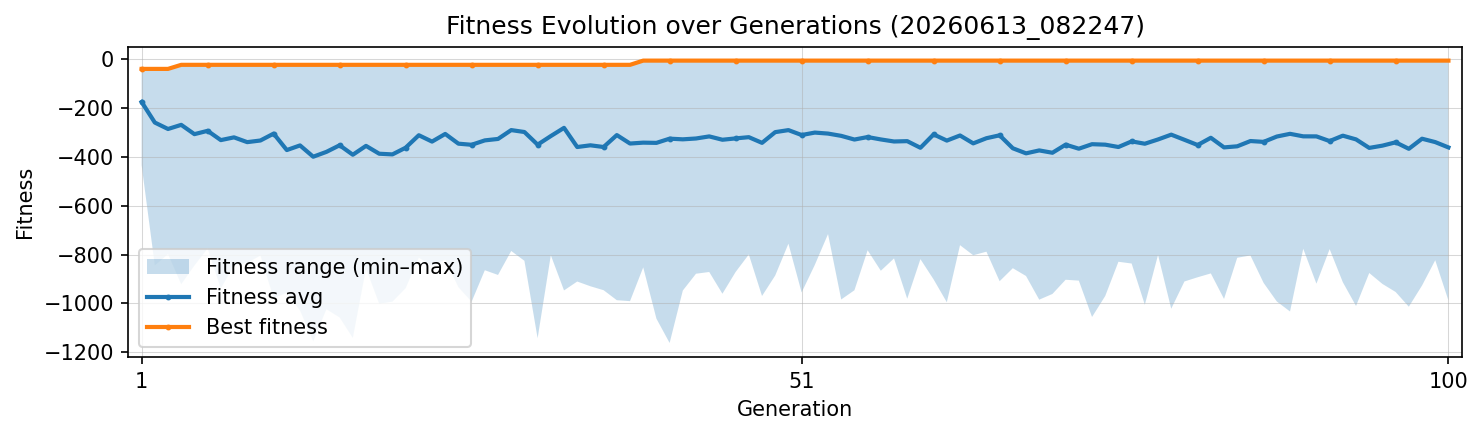

[ga] saved single-run plots to /workspace/__RESULTS__/analysis/gangjin.down/ga/trends


In [3]:
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    single_run_dir = Path(context["single_run_dir"])
    trends_dir = Path(context["trends_dir"])
    analyzer = Analyzer(result_root_path=str(single_run_dir), file_path=0)

    analyzer.plot_evolution_trend(
        xtick_step=50,
        include_corners=SENSOR_COUNT_INCLUDE_CORNERS,
        figsize=(10, 3),
        dpi=150,
        show=True,
        save_path=trends_dir / "sensor_count.png",
        close=True,
    )
    analyzer.plot_coverage_trend(
        xtick_step=50,
        figsize=(10, 3),
        dpi=150,
        show=True,
        save_path=trends_dir / "coverage.png",
        close=True,
    )
    analyzer.plot_fitness_trend(
        xtick_step=50,
        figsize=(10, 3),
        dpi=150,
        show=True,
        save_path=trends_dir / "fitness.png",
        close=True,
    )
    print(f"[{algorithm}] saved single-run plots to {trends_dir}")


## 3. 선택 band의 기본 통계

In [4]:
stats_rows = []
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    single_run_dir = Path(context["single_run_dir"])
    print(f"[{algorithm}]")
    printStats(str(single_run_dir))
    stats = calcStats(str(single_run_dir))
    stats_rows.append(
        {
            "algorithm": algorithm,
            "runs": stats[0],
            "coverage_mean": stats[1],
            "coverage_std": stats[2],
            "corner_mean": stats[3],
            "total_mean": stats[5],
            "optimizer_sec_mean": stats[9],
        }
    )

stats_df = pd.DataFrame(stats_rows).set_index("algorithm")
stats_df.round(3)


[ga]
total runs: 100
[coverage] mean ± std: 97.7069 ± 0.6625
[final] corner sensors mean ± std: 4.00 ± 0.00
[final] total sensors mean ± std: 15.47 ± 0.74
[time] corner mean ± std (sec): 0.000 ± 0.000
[time] optimizer mean ± std (sec): 120.448 ± 1.303


,runs,coverage_mean,coverage_std,corner_mean,total_mean,optimizer_sec_mean
algorithm,,,,,,
ga,100,97.707,0.662,4.0,15.47,120.448


## 4. 센서 간 거리 분석

In [5]:
distance_rows = []
cluster_rows = []
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    single_run_dir = Path(context["single_run_dir"])
    records = list(context["records"])
    cluster = reportCluster(str(single_run_dir), MAP_NAME, grid_m=GRID_M)
    if cluster is not None:
        cluster["algorithm"] = algorithm
        cluster_rows.append(cluster)
    for path, run in records:
        row = nearestStats(finalPoints(run), grid_m=GRID_M)
        row["algorithm"] = algorithm
        row["run_name"] = run.get("run_name", path.stem)
        distance_rows.append(row)

distance_df = pd.DataFrame(distance_rows).set_index(["algorithm", "run_name"])
cluster_df = pd.DataFrame(cluster_rows).set_index("algorithm")
cluster_df.round(3)


[gangjin.down] total runs: 100
[final] 평균 군집거리 mean ± std: 56.857 ± 2.688 m
[final] 군집거리 min / max: 50.122 / 65.091 m


,mean,std,min,max,n_runs
algorithm,,,,,
ga,56.857,2.688,50.122,65.091,100


## 5. 초기 seed 센서수별 수렴 분석

`plotConverge`는 seed band별 세대 평균과 표준편차를 계산하고 수렴 세대를 추정합니다.
`metric='best'`는 세대별 best solution 센서 수, `metric='avg'`는 로그에 기록된 평균 센서 수 기준입니다.
센서 수는 corner 센서를 제외한 내부 배치 센서 기준으로 봅니다.

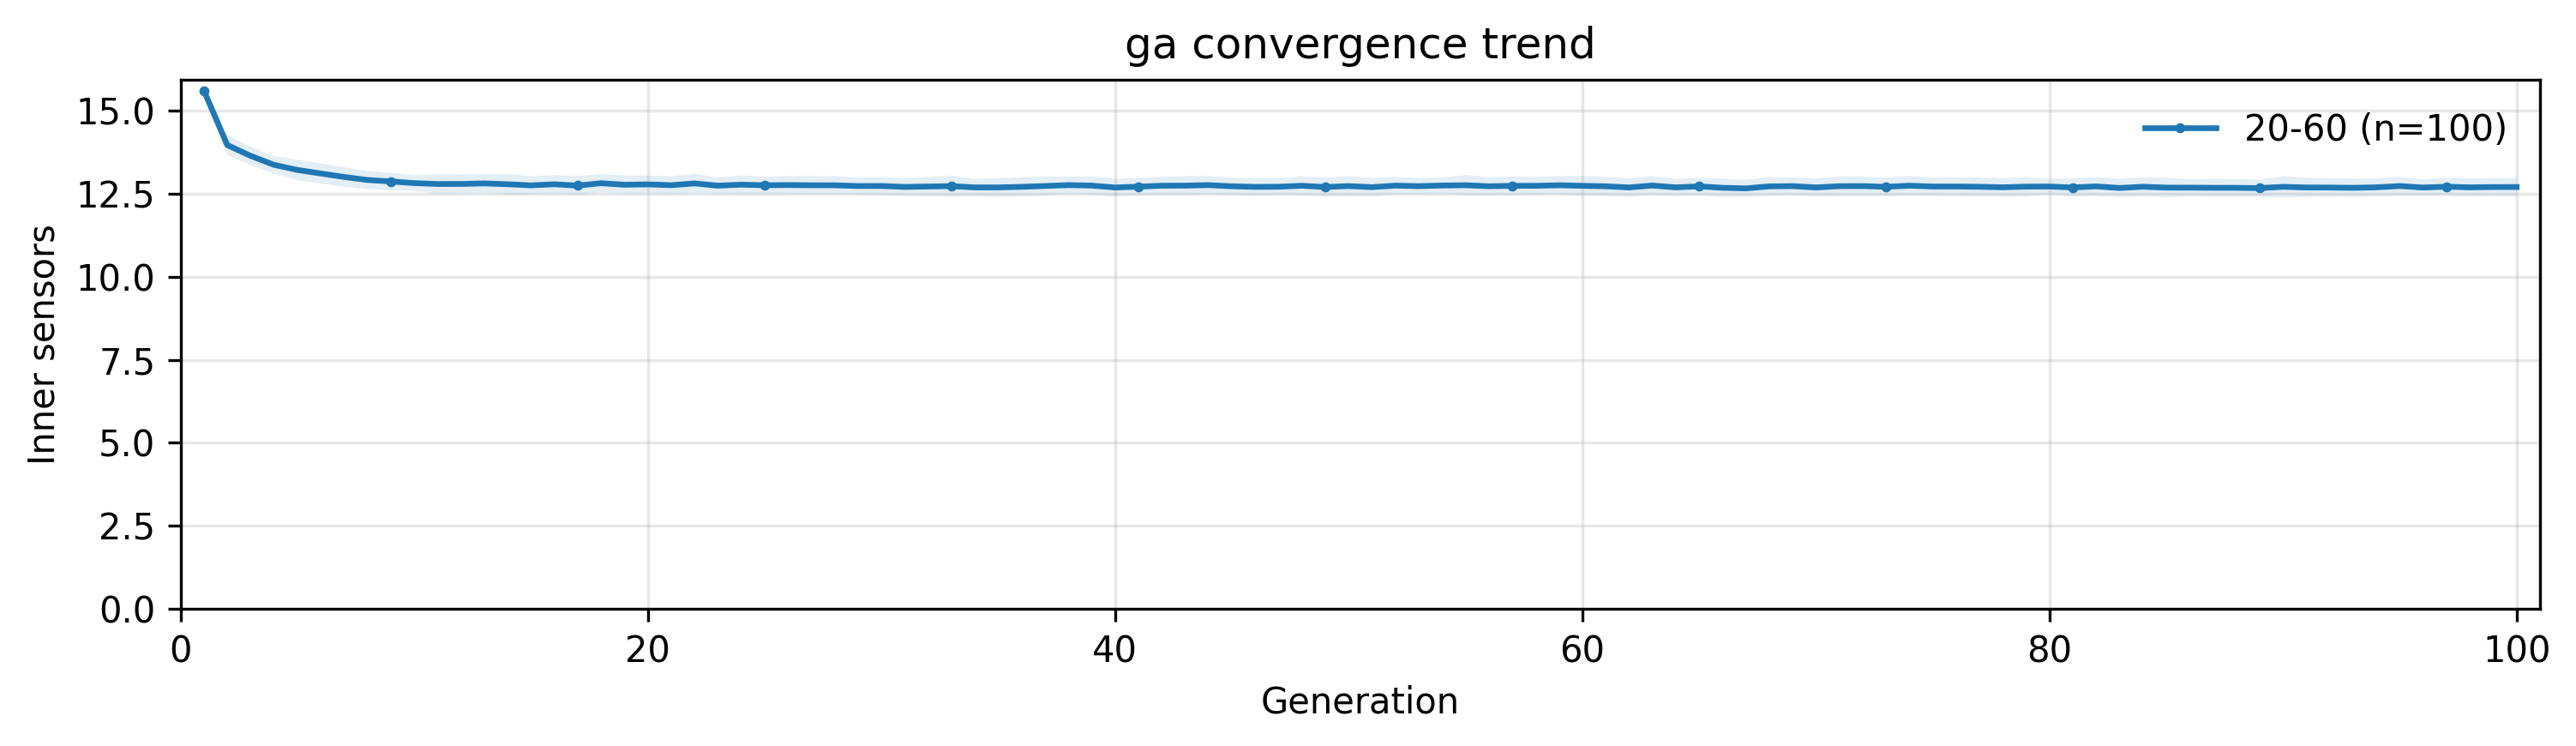

[ga] convergence generation: 2


,convergence_gen
algorithm,
ga,2


In [6]:
convergence_rows = []
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    bands = list(context["bands"])
    trends_dir = Path(context["trends_dir"])
    convergence = plotConverge(
        results_root=RESULTS_ROOT,
        title=f"{algorithm} convergence trend",
        algorithm=algorithm,
        map_name=MAP_NAME,
        seed_bands=bands,
        include_corners=SENSOR_COUNT_INCLUDE_CORNERS,
        metric="avg",
        threshold=1.,
        figsize=(10, 3),
        dpi=300,
        show=True,
        save_path=trends_dir / "convergence.png",
    )
    convergence_gen = convergence["convergence"]["convergence_gen"]
    convergence_rows.append(
        {
            "algorithm": algorithm,
            "convergence_gen": convergence_gen,
        }
    )
    print(f"[{algorithm}] convergence generation: {convergence_gen}")

convergence_df = pd.DataFrame(convergence_rows).set_index("algorithm")
convergence_df


## 6. 전체 커버리지와 중첩 커버리지 분석

`saveReport`는 수렴 그래프, 커버리지/오버랩 그래프, JSON 요약을 함께 저장합니다.
커버리지와 오버랩은 최종 센서 배치를 맵 셀 기준으로 다시 계산합니다.
수렴 그래프의 센서 수는 corner 센서를 제외하고, 커버리지/오버랩 계산에는 최종 배치 전체가 사용됩니다.

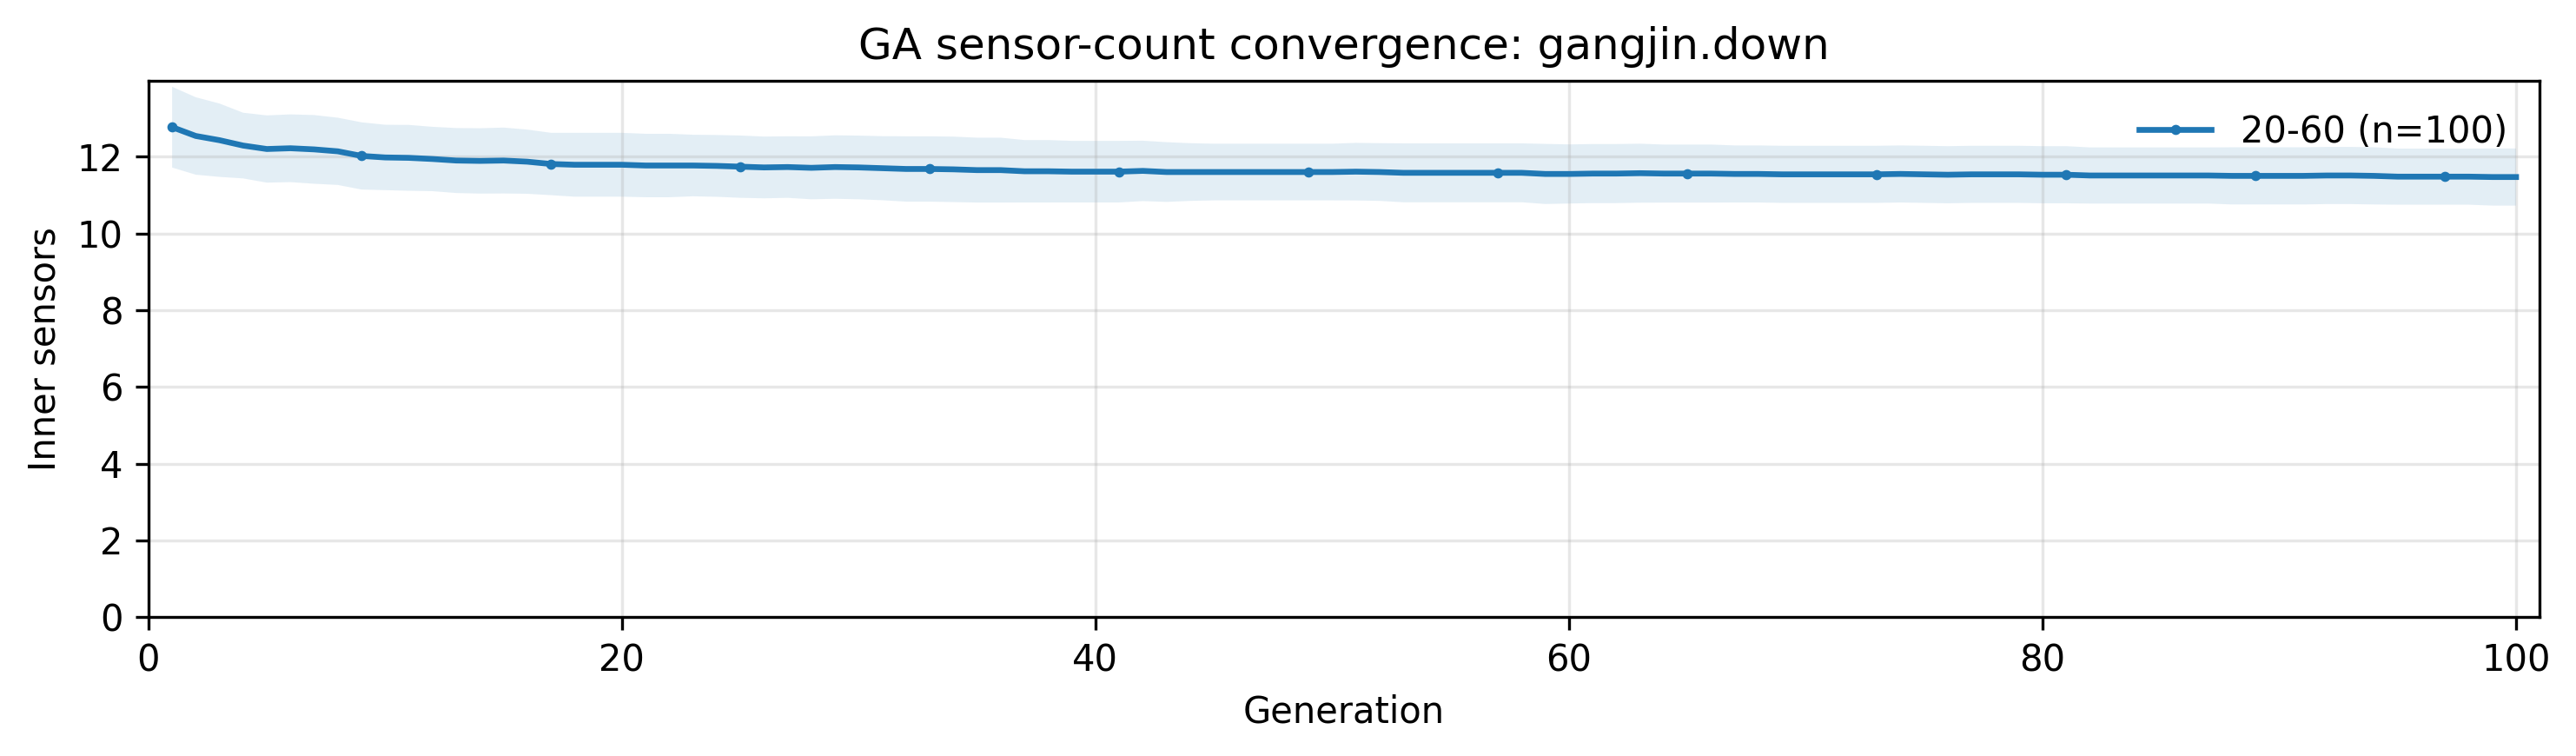

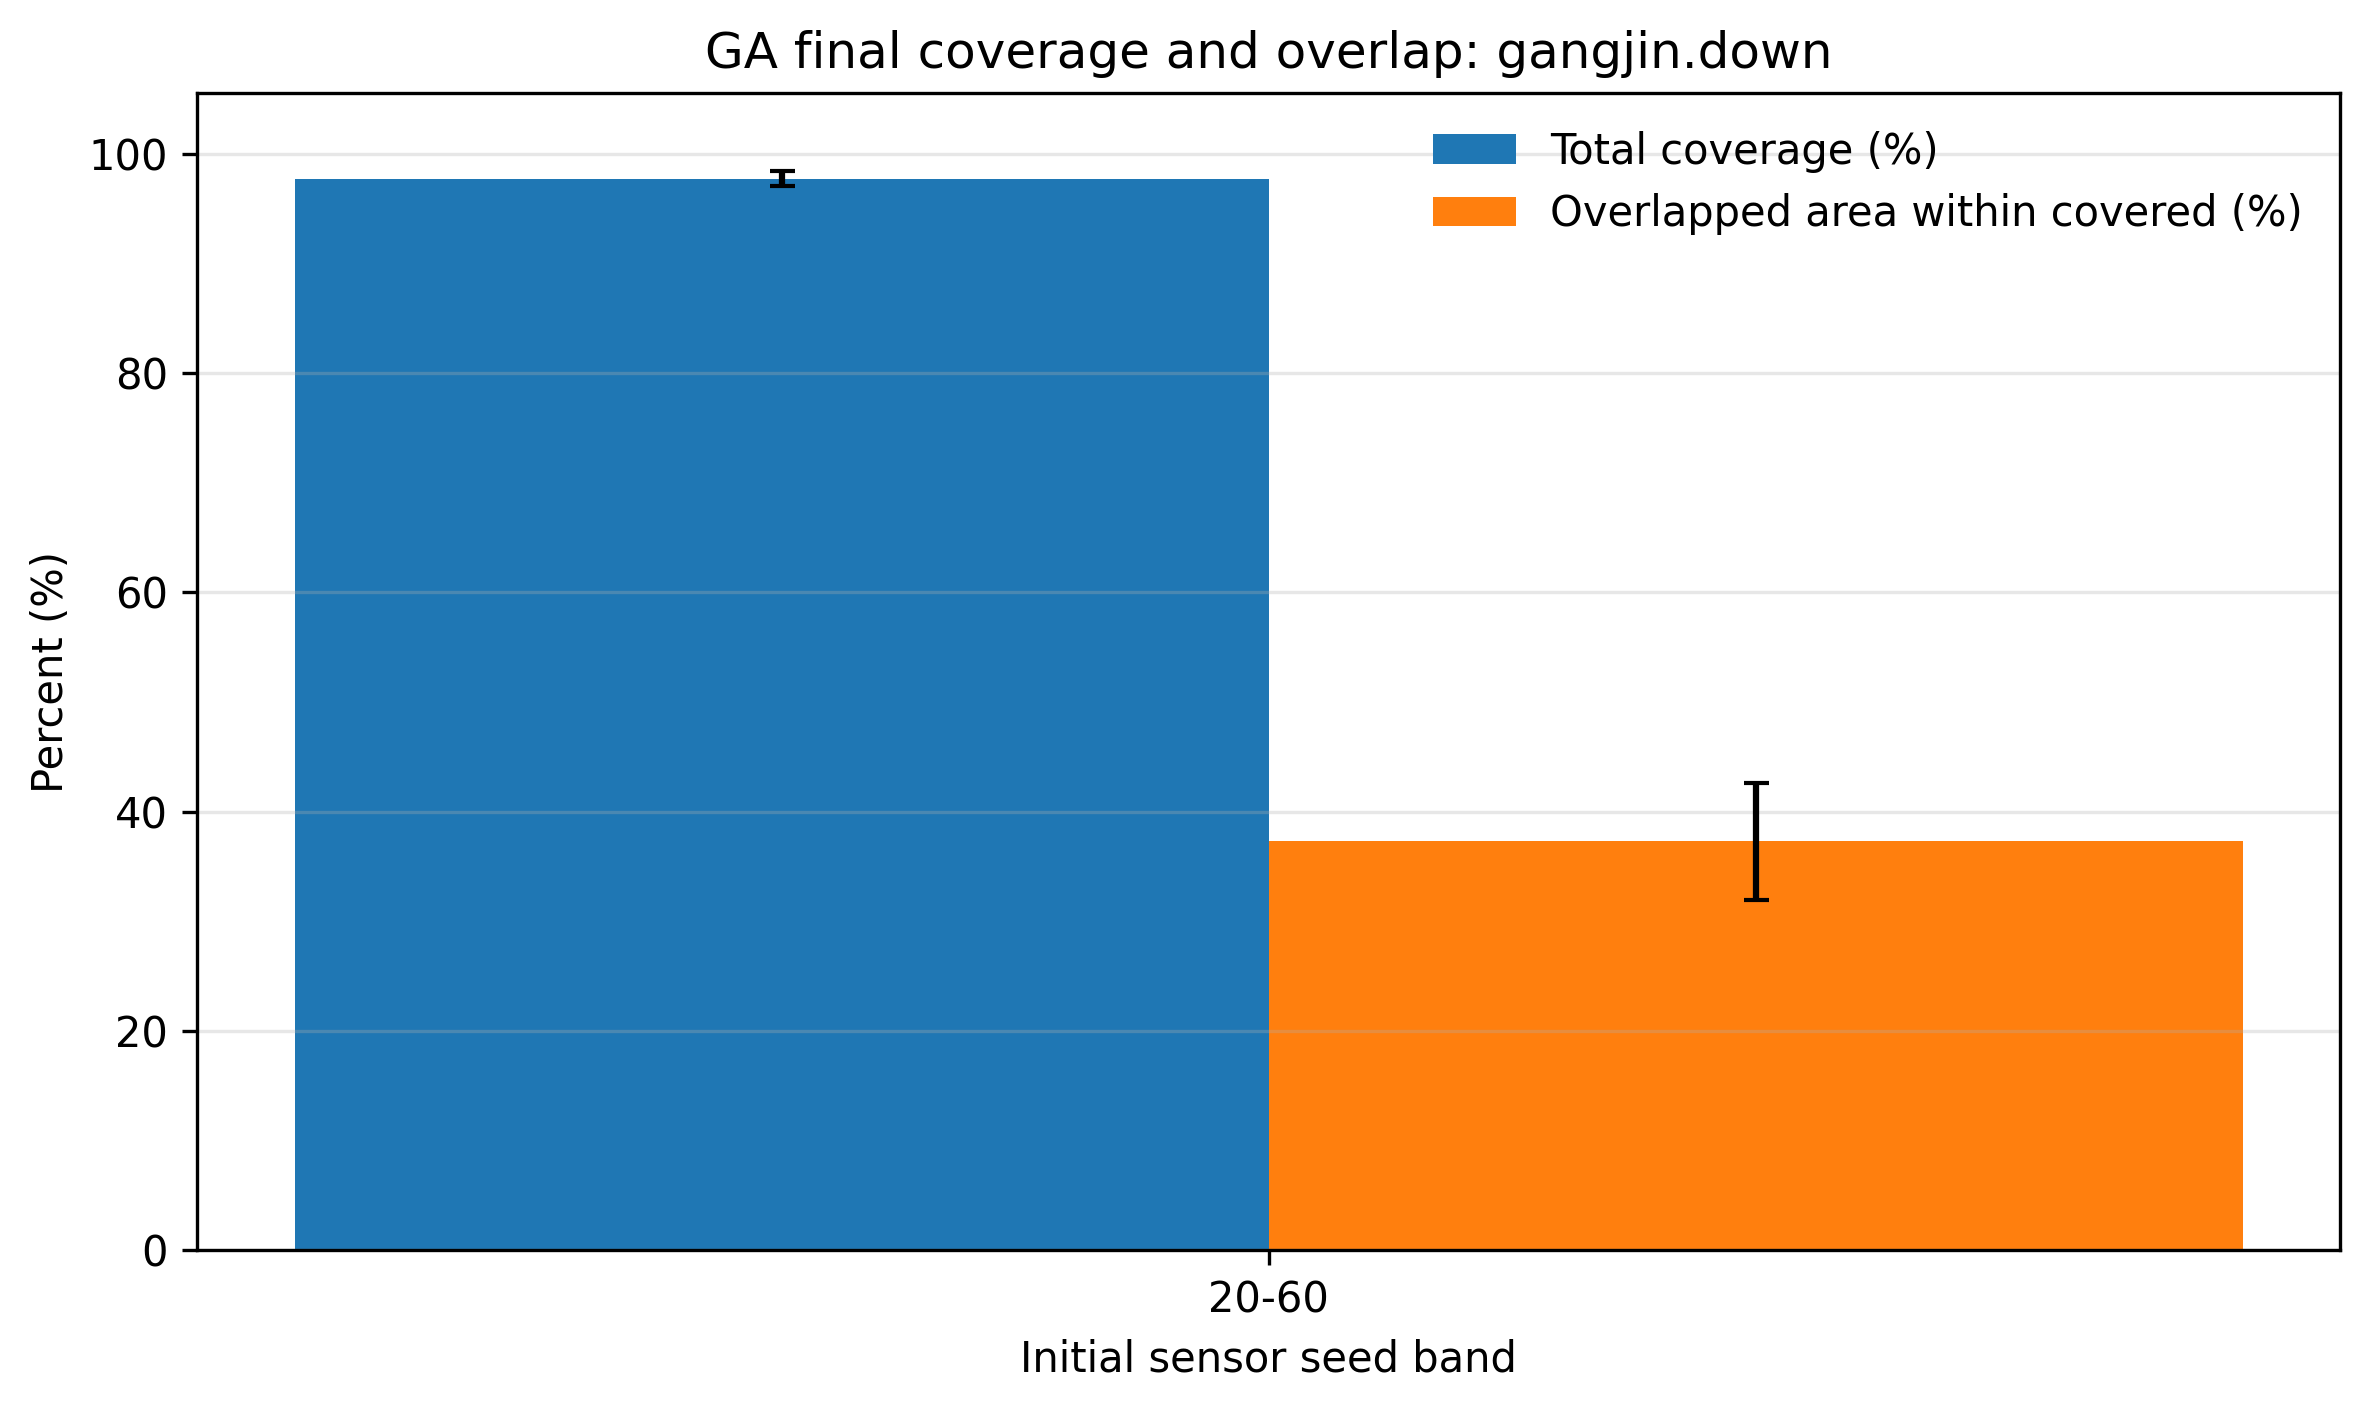

,convergence_plot,coverage_overlap_plot,coverage_overlap_summary
algorithm,,,
ga,/workspace/__RESULTS__/analysis/gangjin.down/g...,/workspace/__RESULTS__/analysis/gangjin.down/g...,/workspace/__RESULTS__/analysis/gangjin.down/g...


In [7]:
report_rows = []
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    bands = list(context["bands"])
    report = saveReport(
        results_root=RESULTS_ROOT,
        algorithm=algorithm,
        map_name=MAP_NAME,
        output_dir=Path(context["report_dir"]),
        summary_dir=Path(context["final_dir"]),
        seed_bands=bands,
        include_corners=SENSOR_COUNT_INCLUDE_CORNERS,
        metric="best",
        threshold=0.5,
        target_values=TARGET_VALUES,
        convergence_figsize=(10, 3),
        dpi=300,
        show=True,
    )
    report_rows.append(
        {
            "algorithm": algorithm,
            **{
                key: report[key]
                for key in [
                    "convergence_plot",
                    "coverage_overlap_plot",
                    "coverage_overlap_summary",
                ]
            },
        }
    )

report_df = pd.DataFrame(report_rows).set_index("algorithm")
report_df


In [8]:
summary_tables = {}
for context in CONTEXTS.values():
    algorithm = str(context["algorithm"])
    bands = list(context["bands"])
    final_dir = Path(context["final_dir"])
    summary = coverSummary(
        results_root=RESULTS_ROOT,
        algorithm=algorithm,
        map_name=MAP_NAME,
        seed_bands=bands,
        target_values=TARGET_VALUES,
    )
    summary_df = pd.DataFrame.from_dict(summary, orient="index")
    csv_path = final_dir / "summary.csv"
    summary_df.to_csv(csv_path, encoding="utf-8-sig")
    summary_tables[algorithm] = summary_df
    print(f"[{algorithm}] saved {csv_path}")

combined_summary = pd.concat(summary_tables, names=["algorithm", "group"])
combined_summary[
    [
        "runs",
        "n_sensors_mean",
        "coverage_percent_mean",
        "overlap_percent_of_target_mean",
        "overlap_percent_of_covered_mean",
        "redundant_hit_percent_mean",
        "logged_final_coverage_mean",
    ]
].round(3)


[ga] saved /workspace/__RESULTS__/analysis/gangjin.down/ga/final/summary.csv


,,runs,n_sensors_mean,coverage_percent_mean,overlap_percent_of_target_mean,overlap_percent_of_covered_mean,redundant_hit_percent_mean,logged_final_coverage_mean
algorithm,group,,,,,,,
ga,20-60,100.0,15.47,97.707,36.45,37.28,28.24,97.707
